# 05 - So sánh mô hình Assignment 05

Notebook này tổng hợp các thí nghiệm Assignment 05 đã hoàn thành mà không retrain mô hình nào. Nó load các artifact split, hyperparameter, metric, và runtime đã lưu từ các notebook theo dataset, rồi so sánh bốn family kiến trúc CNN trên EuroSAT, Oxford-IIIT Pet, và CDC Diabetes.

Tất cả số trong bảng và biểu đồ so sánh đều được load từ result files đã lưu.


## 1. Tổng quan thí nghiệm Assignment

Assignment so sánh một tiến trình kiến trúc CNN có kiểm soát:

- Basic CNN
- AlexNet-inspired CNN
- VGG-inspired CNN
- ResNet-inspired CNN

Với mỗi dataset, phần so sánh kiến trúc dùng protocol riêng đã được chọn trước bằng validation evidence hoặc bằng các ràng buộc data-determined, architecture-determined, và operational. Test set vẫn được giữ riêng khỏi hyperparameter selection.


In [1]:
from pathlib import Path
import json
import math
import sys
import warnings

EXPECTED_PYTHON = Path("C:/Users/anhca/anaconda3/envs/tf312/python.exe")
if Path(sys.executable).resolve() != EXPECTED_PYTHON.resolve():
    raise RuntimeError(f"Wrong Python executable: {sys.executable}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore", category=FutureWarning)

def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if candidate.name == "A05" and (candidate / "AGENTS.md").exists():
            return candidate
    for candidate in candidates:
        possible = candidate / "A05"
        if (possible / "AGENTS.md").exists():
            return possible
    raise RuntimeError("Could not locate A05 project root.")

ROOT = find_project_root()
RESULTS = ROOT / "results"
FIG_DIR = RESULTS / "figures" / "model_comparison"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")
print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow devices: {[device.device_type + ':' + device.name for device in tf.config.list_physical_devices()]}")
print(f"A05 root: {ROOT}")


Python executable: C:\Users\anhca\anaconda3\envs\tf312\python.exe
Python version: 3.12.14
TensorFlow version: 2.21.0
TensorFlow devices: ['CPU:/physical_device:CPU:0']
A05 root: C:\DATA\assign\A05


Cell phía trên xác minh môi trường TensorFlow cố định trước khi xử lý kết quả. TensorFlow chỉ được import để xác nhận notebook đang chạy trong cùng môi trường đã dùng cho các thí nghiệm hoàn tất.


In [2]:
def require_file(path: Path) -> Path:
    if not path.exists():
        raise RuntimeError(f"Required result file is missing: {path.relative_to(ROOT)}")
    return path

metric_files = {
    "EuroSAT": RESULTS / "metrics" / "eurosat_models.csv",
    "Oxford Pets": RESULTS / "metrics" / "oxford_pets_models.csv",
    "Diabetes": RESULTS / "metrics" / "diabetes_models.csv",
}
per_class_files = {
    "EuroSAT": RESULTS / "metrics" / "eurosat_per_class_metrics.csv",
    "Oxford Pets": RESULTS / "metrics" / "oxford_pets_per_class_metrics.csv",
    "Diabetes": RESULTS / "metrics" / "diabetes_per_class_metrics.csv",
}
confusion_pair_files = {
    "EuroSAT": RESULTS / "metrics" / "eurosat_confusion_pairs.csv",
    "Oxford Pets": RESULTS / "metrics" / "oxford_pets_confusion_pairs.csv",
}
hyperparameter_files = {
    "EuroSAT": RESULTS / "hyperparameters" / "eurosat_hyperparameters.csv",
    "Oxford Pets": RESULTS / "hyperparameters" / "oxford_pets_hyperparameters.csv",
    "Diabetes": RESULTS / "hyperparameters" / "diabetes_hyperparameters.csv",
}
selected_protocol_files = {
    "EuroSAT": RESULTS / "hyperparameters" / "eurosat_selected_protocol.csv",
    "Oxford Pets": RESULTS / "hyperparameters" / "oxford_pets_selected_protocol.csv",
    "Diabetes": RESULTS / "hyperparameters" / "diabetes_selected_protocol.csv",
}
split_files = {
    "EuroSAT": {
        "train": RESULTS / "splits" / "eurosat_train.csv",
        "validation": RESULTS / "splits" / "eurosat_val.csv",
        "test": RESULTS / "splits" / "eurosat_test.csv",
    },
    "Oxford Pets": {
        "train": RESULTS / "splits" / "oxford_pets_train.csv",
        "validation": RESULTS / "splits" / "oxford_pets_val.csv",
        "test": RESULTS / "splits" / "oxford_pets_test.csv",
    },
    "Diabetes": {
        "train": RESULTS / "splits" / "diabetes_train.csv",
        "validation": RESULTS / "splits" / "diabetes_val.csv",
        "test": RESULTS / "splits" / "diabetes_test.csv",
    },
}

all_required_paths = []
for mapping in [metric_files, per_class_files, hyperparameter_files, selected_protocol_files]:
    all_required_paths.extend(mapping.values())
for mapping in split_files.values():
    all_required_paths.extend(mapping.values())
all_required_paths.extend(confusion_pair_files.values())
for path in all_required_paths:
    require_file(path)

metrics_raw = {name: pd.read_csv(path) for name, path in metric_files.items()}
per_class_raw = {name: pd.read_csv(path) for name, path in per_class_files.items()}
hyper_raw = {name: pd.read_csv(path) for name, path in hyperparameter_files.items()}
protocol_raw = {name: pd.read_csv(path) for name, path in selected_protocol_files.items()}
splits_raw = {dataset: {split: pd.read_csv(path) for split, path in mapping.items()} for dataset, mapping in split_files.items()}
confusion_pairs_raw = {name: pd.read_csv(path) for name, path in confusion_pair_files.items()}

inventory = pd.DataFrame(
    {
        "relative_path": [str(path.relative_to(ROOT)) for path in sorted(RESULTS.rglob("*")) if path.is_file()],
        "bytes": [path.stat().st_size for path in sorted(RESULTS.rglob("*")) if path.is_file()],
    }
)
inventory["top_folder"] = inventory["relative_path"].str.split("/").str[:2].str.join("/")
print("Loaded required CSV result files.")
print(inventory.groupby("top_folder").size().rename("file_count").to_string())


Loaded required CSV result files.
top_folder
results\dataset_audit.json                                                                    1
results\figures\diabetes\confusion_matrices\alexnet_inspired_confusion_matrix.png             1
results\figures\diabetes\confusion_matrices\basic_confusion_matrix.png                        1
results\figures\diabetes\confusion_matrices\majority_baseline_confusion_matrix.png            1
results\figures\diabetes\confusion_matrices\resnet_inspired_confusion_matrix.png              1
results\figures\diabetes\confusion_matrices\vgg_inspired_confusion_matrix.png                 1
results\figures\diabetes\diabetes_complexity_tradeoffs.png                                    1
results\figures\diabetes\diabetes_final_metrics.png                                           1
results\figures\diabetes\hyperparameters\batch_size_comparison.png                            1
results\figures\diabetes\hyperparameters\class_weight_comparison.png                       

In [3]:
required_metric_columns = {
    "EuroSAT": {
        "model_family", "test_loss", "test_accuracy", "macro_precision", "macro_recall", "macro_f1",
        "trainable_parameter_count", "training_time_seconds", "inference_time_seconds", "best_epoch",
        "early_stopping_activated"
    },
    "Oxford Pets": {
        "model_family", "test_loss", "test_accuracy", "test_macro_precision", "test_macro_recall",
        "test_macro_f1", "trainable_parameter_count", "training_time_seconds",
        "test_inference_time_seconds", "best_epoch", "early_stopping_activated"
    },
    "Diabetes": {
        "model_family", "test_loss", "test_accuracy", "test_macro_precision", "test_macro_recall",
        "test_macro_f1", "test_weighted_f1", "test_class0_recall", "test_class1_prediabetes_recall",
        "test_class2_diabetes_recall", "trainable_parameter_count", "training_time_seconds",
        "test_inference_time_seconds", "best_epoch", "early_stopping_activated"
    },
}

missing = []
for dataset, cols in required_metric_columns.items():
    absent = sorted(cols - set(metrics_raw[dataset].columns))
    if absent:
        missing.append(f"{dataset}: {absent}")

expected_models = {
    "EuroSAT": {"BasicCNN2D", "AlexNetInspired2D", "VGGInspired2D", "ResNetInspired2D"},
    "Oxford Pets": {"BasicCNN2D", "AlexNetInspired2D", "VGGInspired2D", "ResNetInspired2D"},
    "Diabetes": {"BasicCNN1D", "AlexNetInspired1D", "VGGInspired1D", "ResNetInspired1D", "MajorityClassBaseline"},
}
for dataset, expected in expected_models.items():
    observed = set(metrics_raw[dataset]["model_family"])
    absent = sorted(expected - observed)
    if absent:
        missing.append(f"{dataset} missing model rows: {absent}")

if missing:
    raise RuntimeError("Previous experiment results must be fixed before comparison:\n" + "\n".join(missing))

print("Validation passed: all required model rows and metric columns are present.")
for dataset, df in metrics_raw.items():
    print(f"{dataset}: {len(df)} metric rows")


Validation passed: all required model rows and metric columns are present.
EuroSAT: 4 metric rows
Oxford Pets: 4 metric rows
Diabetes: 5 metric rows


## 2. Đặc điểm dataset

Bảng tóm tắt dataset bên dưới được dựng lại từ các split file đã hoàn thành và header của raw diabetes CSV. Bảng này chỉ phục vụ báo cáo; không có training hoặc tuning trong notebook này.


In [4]:
def split_summary(dataset: str) -> dict:
    split_map = splits_raw[dataset]
    row = {
        "dataset": dataset,
        "train": len(split_map["train"]),
        "validation": len(split_map["validation"]),
        "test": len(split_map["test"]),
    }
    row["total_in_splits"] = row["train"] + row["validation"] + row["test"]
    return row

dataset_rows = [split_summary(name) for name in ["EuroSAT", "Oxford Pets", "Diabetes"]]

dataset_rows[0].update(
    {
        "classes": int(pd.concat(splits_raw["EuroSAT"].values())["class_name"].nunique()),
        "input_representation": "64x64 RGB image",
        "sample_policy": "All verified EuroSAT RGB images in stratified split",
    }
)
dataset_rows[1].update(
    {
        "classes": int(pd.concat(splits_raw["Oxford Pets"].values())["class_name"].nunique()),
        "input_representation": "selected RGB resize from official annotations",
        "sample_policy": "Only annotations/trainval.txt and annotations/test.txt",
    }
)

diabetes_path = ROOT / "datasets" / "diabetes" / "diabetes_012_health_indicators_BRFSS2015.csv"
require_file(diabetes_path)
diabetes_raw = pd.read_csv(diabetes_path)
dataset_rows[2].update(
    {
        "classes": int(diabetes_raw["Diabetes_012"].nunique()),
        "input_representation": "21 predictors as Conv1D sequence (21, 1)",
        "sample_policy": "Raw CDC table split stratified by Diabetes_012",
    }
)

dataset_characteristics = pd.DataFrame(dataset_rows)
print(dataset_characteristics.to_string(index=False))


    dataset  train  validation  test  total_in_splits  classes                          input_representation                                          sample_policy
    EuroSAT  18900        4050  4050            27000       10                               64x64 RGB image    All verified EuroSAT RGB images in stratified split
Oxford Pets   2944         736  3669             7349       37 selected RGB resize from official annotations Only annotations/trainval.txt and annotations/test.txt
   Diabetes 177576       38052 38052           253680        3      21 predictors as Conv1D sequence (21, 1)         Raw CDC table split stratified by Diabetes_012


In [5]:
class_distribution_rows = []
for dataset in ["EuroSAT", "Oxford Pets"]:
    combined = pd.concat(splits_raw[dataset].values(), ignore_index=True)
    for class_name, count in combined["class_name"].value_counts().sort_index().items():
        class_distribution_rows.append({"dataset": dataset, "class": class_name, "count": int(count)})

diabetes_counts = diabetes_raw["Diabetes_012"].value_counts().sort_index()
diabetes_names = {0.0: "No diabetes", 1.0: "Prediabetes", 2.0: "Diabetes"}
for label, count in diabetes_counts.items():
    class_distribution_rows.append({"dataset": "Diabetes", "class": diabetes_names.get(label, str(label)), "count": int(count)})

class_distribution = pd.DataFrame(class_distribution_rows)
print(class_distribution.groupby("dataset")["count"].describe().round(2).to_string())


             count      mean        std     min      25%      50%       75%       max
dataset                                                                              
Diabetes       3.0  84560.00  112890.60  4631.0  19988.5  35346.0  124524.5  213703.0
EuroSAT       10.0   2700.00     349.60  2000.0   2500.0   2750.0    3000.0    3000.0
Oxford Pets   37.0    198.62       3.52   184.0    199.0    200.0     200.0     200.0


## 3. Sự phát triển kiến trúc

Các family mô hình được thiết kế thành một tiến trình khái niệm rõ ràng. Basic CNN là baseline convolution đơn giản. AlexNet-inspired tăng capacity biểu diễn bằng nhiều stage convolution hơn. VGG-inspired dùng các block convolution kernel nhỏ lặp lại. ResNet-inspired thêm residual learning rõ ràng qua `y = F(x) + shortcut(x)`.

Các biến thể này là implementation giáo dục, CPU-aware, không phải tái tạo lịch sử ở full scale. Mô hình ảnh dùng Conv2D. Mô hình diabetes dùng Conv1D như adaptation theo yêu cầu assignment cho 21 predictor tabular, đồng thời giữ nguyên thứ tự feature gốc.


In [6]:
architecture_summary = pd.DataFrame(
    [
        {"family": "Basic CNN", "main_idea": "simple convolutional baseline", "residual": "no", "image_variant": "Conv2D", "diabetes_variant": "Conv1D"},
        {"family": "AlexNet-inspired", "main_idea": "deeper feature extraction and capacity", "residual": "no", "image_variant": "Conv2D", "diabetes_variant": "Conv1D"},
        {"family": "VGG-inspired", "main_idea": "repeated small-kernel blocks", "residual": "no", "image_variant": "Conv2D", "diabetes_variant": "Conv1D"},
        {"family": "ResNet-inspired", "main_idea": "residual learning y = F(x) + x", "residual": "yes", "image_variant": "Conv2D", "diabetes_variant": "Conv1D"},
    ]
)
print(architecture_summary.to_string(index=False))


          family                              main_idea residual image_variant diabetes_variant
       Basic CNN          simple convolutional baseline       no        Conv2D           Conv1D
AlexNet-inspired deeper feature extraction and capacity       no        Conv2D           Conv1D
    VGG-inspired           repeated small-kernel blocks       no        Conv2D           Conv1D
 ResNet-inspired         residual learning y = F(x) + x      yes        Conv2D           Conv1D


## 4. Tóm tắt chọn siêu tham số

Bảng này kết hợp từng protocol item đã chọn với candidate values có trong các file hyperparameter đã lưu. Những dòng không có candidate grid là quyết định data-determined, architecture-determined, operational, hoặc controlled protocol choice đã được ghi trong tài liệu trước.


In [7]:
def candidates_for_decision(dataset: str, decision: str) -> str:
    hp = hyper_raw[dataset]
    decision_lower = decision.lower()
    mapping = [
        ("learning rate", "learning_rate"),
        ("batch size", "batch_size"),
        ("image resolution", "resolution"),
        ("input resolution", "resolution"),
        ("preprocessing", "scaling"),
        ("class weighting", "class_weight"),
    ]
    for needle, experiment_type in mapping:
        if needle in decision_lower and "experiment_type" in hp.columns:
            vals = hp.loc[hp["experiment_type"].eq(experiment_type), "candidate_value"].dropna().astype(str).unique().tolist()
            return ", ".join(vals) if vals else "not a grid search item"
    if "augmentation" in decision_lower and "experiment_type" in hp.columns:
        vals = hp.loc[hp["experiment_type"].eq("augmentation"), "candidate_value"].dropna().astype(str).unique().tolist()
        vals = ["none", *vals] if "none" not in vals else vals
        return ", ".join(vals) if vals else "none"
    if "regularization" in decision_lower or "dropout" in decision_lower:
        if "dropout_rate" in hp.columns:
            vals = sorted({str(v) for v in hp["dropout_rate"].dropna().unique()})
            if vals == ["0.0"] or vals == ["0"]:
                return "none; dropout experiment not triggered by validation diagnostics"
            return ", ".join(vals)
        return "none"
    if "max_epochs" in decision_lower or "max epoch" in decision_lower:
        vals = sorted({str(int(v)) for v in hp["max_epochs"].dropna().unique()})
        return ", ".join(vals) if vals else "operational bound"
    if "early" in decision_lower:
        vals = sorted({str(int(v)) for v in hp["patience"].dropna().unique()})
        return "patience " + ", ".join(vals) if vals else "operational bound"
    return "not applicable"

hyper_rows = []
for dataset, protocol in protocol_raw.items():
    for _, row in protocol.iterrows():
        hyper_rows.append(
            {
                "dataset": dataset,
                "decision": row["decision"],
                "selected_value": row["selected_value"],
                "candidate_values_tested": candidates_for_decision(dataset, row["decision"]),
                "evidence_used": row["evidence_or_reason"],
                "decision_category": row["classification"],
            }
        )

hyperparameter_summary = pd.DataFrame(hyper_rows)
print(hyperparameter_summary.to_string(index=False))


    dataset                           decision                                                         selected_value                                          candidate_values_tested                                                                                                                       evidence_used                                     decision_category
    EuroSAT                   input resolution                                                              64x64 RGB                                           not a grid search item                                                                                            All EuroSAT files verified as 64x64 RGB.                                       data-determined
    EuroSAT                  number of classes                                                                     10                                                   not applicable                                                                                

In [8]:
def normalize_metrics(dataset: str, df: pd.DataFrame) -> pd.DataFrame:
    if dataset == "EuroSAT":
        out = df.assign(
            dataset=dataset,
            accuracy=df["test_accuracy"],
            macro_precision=df["macro_precision"],
            macro_recall=df["macro_recall"],
            macro_f1=df["macro_f1"],
            weighted_f1=np.nan,
            parameters=df["trainable_parameter_count"],
            training_time_seconds=df["training_time_seconds"],
            inference_time_seconds=df["inference_time_seconds"],
        )
    else:
        out = df.assign(
            dataset=dataset,
            accuracy=df["test_accuracy"],
            macro_precision=df["test_macro_precision"],
            macro_recall=df["test_macro_recall"],
            macro_f1=df["test_macro_f1"],
            weighted_f1=df["test_weighted_f1"] if "test_weighted_f1" in df.columns else np.nan,
            parameters=df["trainable_parameter_count"],
            training_time_seconds=df["training_time_seconds"],
            inference_time_seconds=df["test_inference_time_seconds"],
        )
    keep = [
        "dataset", "model_family", "key", "test_loss", "accuracy", "macro_precision", "macro_recall",
        "macro_f1", "weighted_f1", "parameters", "training_time_seconds", "inference_time_seconds",
        "best_epoch", "epochs_run", "early_stopping_activated"
    ]
    for optional in ["test_class0_recall", "test_class1_prediabetes_recall", "test_class2_diabetes_recall"]:
        if optional in out.columns:
            keep.append(optional)
    return out[keep]

comparison = pd.concat([normalize_metrics(dataset, df) for dataset, df in metrics_raw.items()], ignore_index=True)
model_order = {
    "BasicCNN2D": 0, "AlexNetInspired2D": 1, "VGGInspired2D": 2, "ResNetInspired2D": 3,
    "BasicCNN1D": 0, "AlexNetInspired1D": 1, "VGGInspired1D": 2, "ResNetInspired1D": 3,
    "MajorityClassBaseline": -1,
}
display_names = {
    "BasicCNN2D": "Basic CNN", "AlexNetInspired2D": "AlexNet-inspired", "VGGInspired2D": "VGG-inspired", "ResNetInspired2D": "ResNet-inspired",
    "BasicCNN1D": "Basic CNN", "AlexNetInspired1D": "AlexNet-inspired", "VGGInspired1D": "VGG-inspired", "ResNetInspired1D": "ResNet-inspired",
    "MajorityClassBaseline": "Majority baseline",
}
comparison["model_display"] = comparison["model_family"].map(display_names)
comparison["model_order"] = comparison["model_family"].map(model_order)
architecture_comparison = comparison[comparison["model_family"].ne("MajorityClassBaseline")].copy()
architecture_comparison = architecture_comparison.sort_values(["dataset", "model_order"])

print("Combined metrics loaded from source CSV files:")
print(
    architecture_comparison[
        ["dataset", "model_display", "accuracy", "macro_precision", "macro_recall", "macro_f1", "parameters", "training_time_seconds", "inference_time_seconds"]
    ].round(6).to_string(index=False)
)


Combined metrics loaded from source CSV files:
    dataset    model_display  accuracy  macro_precision  macro_recall  macro_f1  parameters  training_time_seconds  inference_time_seconds
   Diabetes        Basic CNN  0.695285         0.448806      0.503942  0.439204        2787               6.467587                0.092471
   Diabetes AlexNet-inspired  0.607984         0.480219      0.501598  0.407489       29635              12.364384                0.146516
   Diabetes     VGG-inspired  0.679334         0.432166      0.492058  0.426122       38299              10.209813                0.191927
   Diabetes  ResNet-inspired  0.712394         0.432085      0.493311  0.435588       44387              11.513357                0.251095
    EuroSAT        Basic CNN  0.739753         0.744031      0.726267  0.725624       24202             365.389023               40.820163
    EuroSAT AlexNet-inspired  0.111111         0.011111      0.100000  0.020000      260170             677.584922     

## 5. So sánh bốn mô hình EuroSAT

Phần so sánh EuroSAT dùng final metrics đã lưu trong `results/metrics/eurosat_models.csv`.


In [9]:
cols = ["model_display", "test_loss", "accuracy", "macro_precision", "macro_recall", "macro_f1", "parameters", "training_time_seconds", "inference_time_seconds", "best_epoch", "early_stopping_activated"]
eurosat_table = architecture_comparison.query("dataset == 'EuroSAT'")[cols].copy()
print(eurosat_table.round(6).to_string(index=False))


   model_display  test_loss  accuracy  macro_precision  macro_recall  macro_f1  parameters  training_time_seconds  inference_time_seconds  best_epoch  early_stopping_activated
       Basic CNN   0.706818  0.739753         0.744031      0.726267  0.725624       24202             365.389023               40.820163           6                     False
AlexNet-inspired   2.295519  0.111111         0.011111      0.100000  0.020000      260170             677.584922               82.137570           2                      True
    VGG-inspired   2.295522  0.111111         0.011111      0.100000  0.020000      304810            1071.420659               64.267237           2                      True
 ResNet-inspired   2.295525  0.111111         0.011111      0.100000  0.020000      324490            1467.592041               16.271885           2                      True


## 6. So sánh bốn mô hình Oxford Pets

Phần so sánh Oxford-IIIT Pet chỉ dùng các sample annotation chính thức và load final metrics đã lưu trong `results/metrics/oxford_pets_models.csv`.


In [10]:
oxford_table = architecture_comparison.query("dataset == 'Oxford Pets'")[cols].copy()
print(oxford_table.round(6).to_string(index=False))


   model_display  test_loss  accuracy  macro_precision  macro_recall  macro_f1  parameters  training_time_seconds  inference_time_seconds  best_epoch  early_stopping_activated
       Basic CNN   3.553684  0.047152         0.016036      0.047756  0.019787       25957              20.747897                6.525366           5                     False
AlexNet-inspired   3.586190  0.040883         0.007782      0.041198  0.011541      263653              36.932364                7.808555           5                     False
    VGG-inspired   3.610884  0.027255         0.000737      0.027027  0.001434      308293              70.055179                9.499183           5                     False
 ResNet-inspired   3.545843  0.043336         0.005067      0.043118  0.008012      327973              95.512476               10.635546           5                     False


## 7. So sánh bốn mô hình Diabetes

Phần so sánh diabetes dùng các adaptation Conv1D. Majority-class baseline được trình bày riêng vì accuracy đơn thuần có thể gây hiểu nhầm trên target mất cân bằng này.


In [11]:
diabetes_cols = cols + ["weighted_f1", "test_class0_recall", "test_class1_prediabetes_recall", "test_class2_diabetes_recall"]
diabetes_table = comparison.query("dataset == 'Diabetes'").sort_values("model_order")[diabetes_cols].copy()
print(diabetes_table.round(6).to_string(index=False))


    model_display  test_loss  accuracy  macro_precision  macro_recall  macro_f1  parameters  training_time_seconds  inference_time_seconds  best_epoch  early_stopping_activated  weighted_f1  test_class0_recall  test_class1_prediabetes_recall  test_class2_diabetes_recall
Majority baseline        NaN  0.842400         0.280800      0.333333  0.304820           0               0.000000                0.000000           0                     False     0.770340            1.000000                        0.000000                     0.000000
        Basic CNN   0.761032  0.695285         0.448806      0.503942  0.439204        2787               6.467587                0.092471           5                     False     0.755698            0.732678                        0.251799                     0.527348
 AlexNet-inspired   0.814713  0.607984         0.480219      0.501598  0.407489       29635              12.364384                0.146516           3                     False     0.7089

## 8. Accuracy so với Macro-F1

Accuracy và macro-F1 được hiển thị cạnh nhau vì class imbalance và lỗi theo lớp có thể làm accuracy trông mạnh hơn hiệu năng cân bằng giữa các lớp.


Saved results\figures\model_comparison\accuracy_by_dataset.png


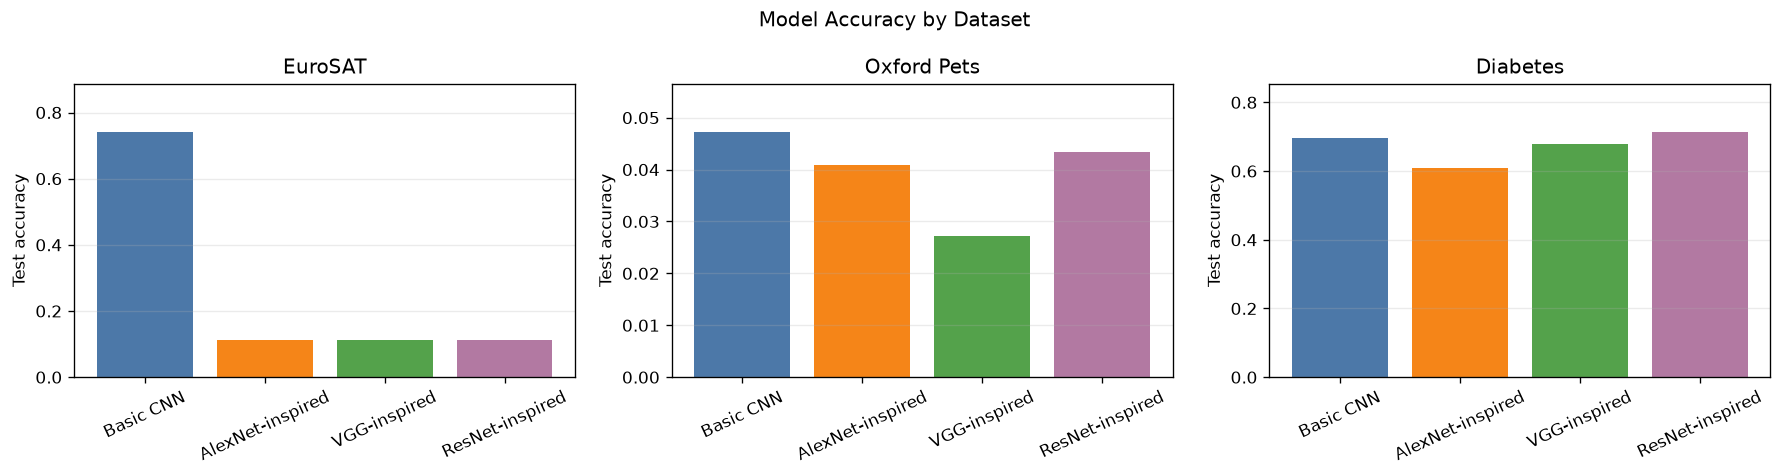

In [12]:
def plot_metric_bars(metric: str, title: str, ylabel: str, filename: str):
    datasets = ["EuroSAT", "Oxford Pets", "Diabetes"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    for ax, dataset in zip(axes, datasets):
        data = architecture_comparison.query("dataset == @dataset").sort_values("model_order")
        ax.bar(data["model_display"], data[metric], color=["#4c78a8", "#f58518", "#54a24b", "#b279a2"])
        ax.set_title(dataset)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=25)
        ax.set_ylim(0, max(0.05, data[metric].max() * 1.2))
        ax.grid(axis="y", alpha=0.25)
    fig.suptitle(title)
    fig.tight_layout()
    output_path = FIG_DIR / filename
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Saved {output_path.relative_to(ROOT)}")

plot_metric_bars("accuracy", "Model Accuracy by Dataset", "Test accuracy", "accuracy_by_dataset.png")


Saved results\figures\model_comparison\macro_f1_by_dataset.png


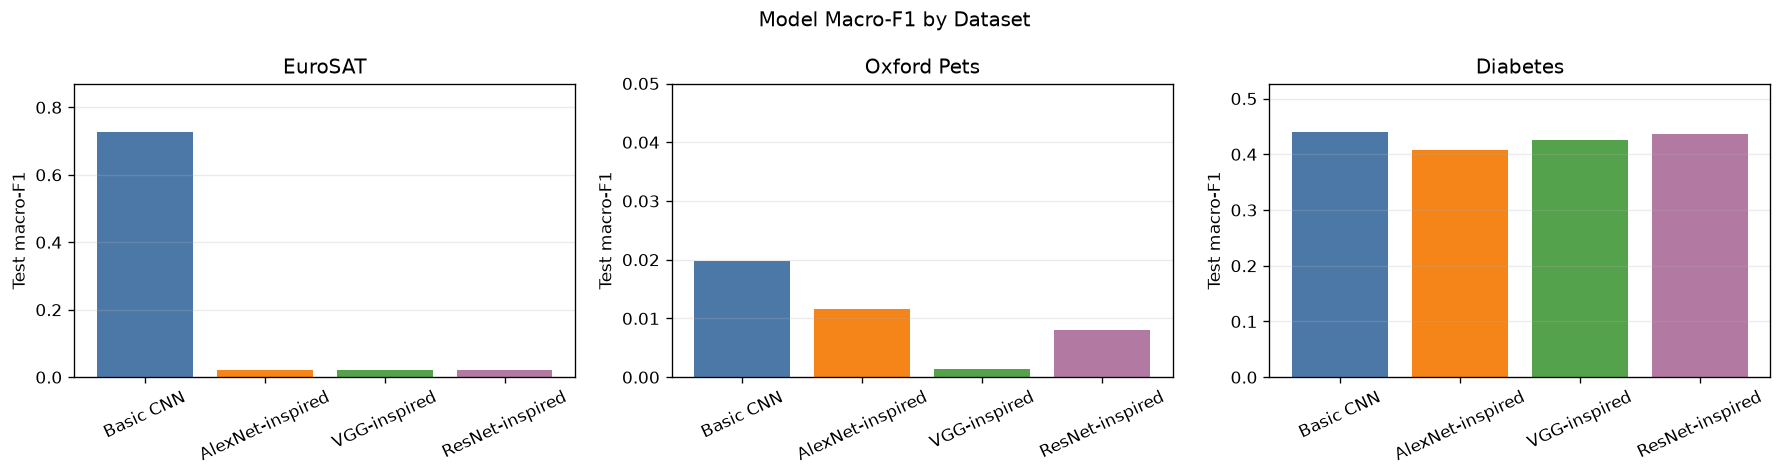

In [13]:
plot_metric_bars("macro_f1", "Model Macro-F1 by Dataset", "Test macro-F1", "macro_f1_by_dataset.png")


In [14]:
accuracy_f1_gap = architecture_comparison.assign(accuracy_minus_macro_f1=lambda df: df["accuracy"] - df["macro_f1"])
print(
    accuracy_f1_gap[["dataset", "model_display", "accuracy", "macro_f1", "accuracy_minus_macro_f1"]]
    .sort_values("accuracy_minus_macro_f1", ascending=False)
    .round(6)
    .to_string(index=False)
)


    dataset    model_display  accuracy  macro_f1  accuracy_minus_macro_f1
   Diabetes  ResNet-inspired  0.712394  0.435588                 0.276806
   Diabetes        Basic CNN  0.695285  0.439204                 0.256081
   Diabetes     VGG-inspired  0.679334  0.426122                 0.253212
   Diabetes AlexNet-inspired  0.607984  0.407489                 0.200495
    EuroSAT AlexNet-inspired  0.111111  0.020000                 0.091111
    EuroSAT     VGG-inspired  0.111111  0.020000                 0.091111
    EuroSAT  ResNet-inspired  0.111111  0.020000                 0.091111
Oxford Pets  ResNet-inspired  0.043336  0.008012                 0.035325
Oxford Pets AlexNet-inspired  0.040883  0.011541                 0.029342
Oxford Pets        Basic CNN  0.047152  0.019787                 0.027365
Oxford Pets     VGG-inspired  0.027255  0.001434                 0.025821
    EuroSAT        Basic CNN  0.739753  0.725624                 0.014129


## 9. Hiệu năng so với parameter count

Parameter count được vẽ trên trục x logarithmic và tách theo dataset để các mô hình ảnh và tabular không bị đặt trên một scale gây hiểu nhầm.


Saved results\figures\model_comparison\parameters_vs_macro_f1.png


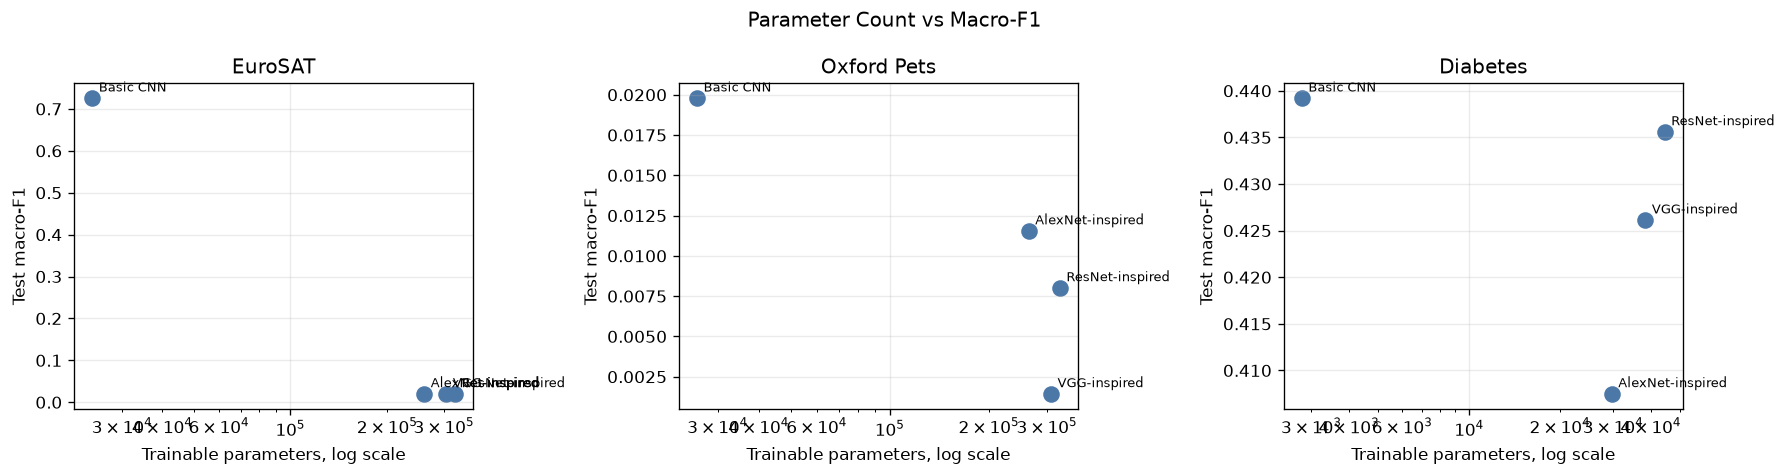

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, dataset in zip(axes, ["EuroSAT", "Oxford Pets", "Diabetes"]):
    data = architecture_comparison.query("dataset == @dataset").sort_values("model_order")
    ax.scatter(data["parameters"], data["macro_f1"], s=80, color="#4c78a8")
    for _, row in data.iterrows():
        ax.annotate(row["model_display"], (row["parameters"], row["macro_f1"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set_xscale("log")
    ax.set_title(dataset)
    ax.set_xlabel("Trainable parameters, log scale")
    ax.set_ylabel("Test macro-F1")
    ax.grid(alpha=0.25)
fig.suptitle("Parameter Count vs Macro-F1")
fig.tight_layout()
output_path = FIG_DIR / "parameters_vs_macro_f1.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"Saved {output_path.relative_to(ROOT)}")


## 10. Hiệu năng so với training time

Training time cũng được tách theo dataset vì các dataset và biến thể mô hình có quy mô tính toán khác nhau.


Saved results\figures\model_comparison\training_time_vs_macro_f1.png


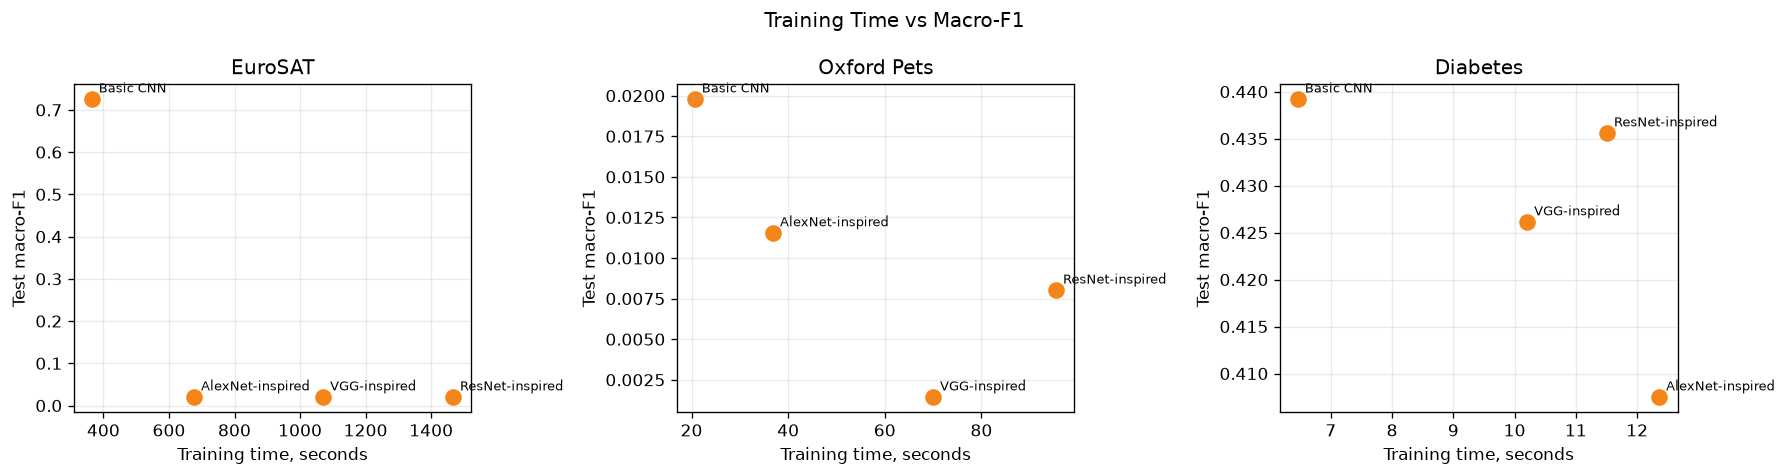

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, dataset in zip(axes, ["EuroSAT", "Oxford Pets", "Diabetes"]):
    data = architecture_comparison.query("dataset == @dataset").sort_values("model_order")
    ax.scatter(data["training_time_seconds"], data["macro_f1"], s=80, color="#f58518")
    for _, row in data.iterrows():
        ax.annotate(row["model_display"], (row["training_time_seconds"], row["macro_f1"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set_title(dataset)
    ax.set_xlabel("Training time, seconds")
    ax.set_ylabel("Test macro-F1")
    ax.grid(alpha=0.25)
fig.suptitle("Training Time vs Macro-F1")
fig.tight_layout()
output_path = FIG_DIR / "training_time_vs_macro_f1.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"Saved {output_path.relative_to(ROOT)}")


## 11. Phân tích phát triển kiến trúc

Các bảng sau tính trade-off quan sát được từ metrics đã lưu. Chúng chỉ ra nơi độ sâu thêm vào có ích, nơi không có ích, nơi parameter growth đem lại lợi ích nhỏ, và nơi chi phí CPU tăng lên.


In [17]:
analysis_rows = []
for dataset, data in architecture_comparison.groupby("dataset"):
    data = data.sort_values("model_order")
    basic = data.iloc[0]
    best = data.loc[data["macro_f1"].idxmax()]
    largest = data.loc[data["parameters"].idxmax()]
    slowest = data.loc[data["training_time_seconds"].idxmax()]
    analysis_rows.append(
        {
            "dataset": dataset,
            "basic_macro_f1": basic["macro_f1"],
            "best_macro_f1_model": best["model_display"],
            "best_macro_f1": best["macro_f1"],
            "best_minus_basic_macro_f1": best["macro_f1"] - basic["macro_f1"],
            "largest_model": largest["model_display"],
            "largest_parameters": int(largest["parameters"]),
            "slowest_model": slowest["model_display"],
            "slowest_training_seconds": slowest["training_time_seconds"],
        }
    )
tradeoff_summary = pd.DataFrame(analysis_rows)
print(tradeoff_summary.round(6).to_string(index=False))


    dataset  basic_macro_f1 best_macro_f1_model  best_macro_f1  best_minus_basic_macro_f1   largest_model  largest_parameters    slowest_model  slowest_training_seconds
   Diabetes        0.439204           Basic CNN       0.439204                        0.0 ResNet-inspired               44387 AlexNet-inspired                 12.364384
    EuroSAT        0.725624           Basic CNN       0.725624                        0.0 ResNet-inspired              324490  ResNet-inspired               1467.592041
Oxford Pets        0.019787           Basic CNN       0.019787                        0.0 ResNet-inspired              327973  ResNet-inspired                 95.512476


In [18]:
ratio_rows = []
for dataset, data in architecture_comparison.groupby("dataset"):
    data = data.sort_values("model_order")
    basic = data.iloc[0]
    for _, row in data.iloc[1:].iterrows():
        ratio_rows.append(
            {
                "dataset": dataset,
                "model": row["model_display"],
                "macro_f1_gain_vs_basic": row["macro_f1"] - basic["macro_f1"],
                "parameter_ratio_vs_basic": row["parameters"] / basic["parameters"] if basic["parameters"] else np.nan,
                "training_time_ratio_vs_basic": row["training_time_seconds"] / basic["training_time_seconds"] if basic["training_time_seconds"] else np.nan,
            }
        )
ratio_summary = pd.DataFrame(ratio_rows)
print(ratio_summary.round(6).to_string(index=False))


    dataset            model  macro_f1_gain_vs_basic  parameter_ratio_vs_basic  training_time_ratio_vs_basic
   Diabetes AlexNet-inspired               -0.031716                 10.633297                      1.911746
   Diabetes     VGG-inspired               -0.013083                 13.742017                      1.578612
   Diabetes  ResNet-inspired               -0.003616                 15.926444                      1.780163
    EuroSAT AlexNet-inspired               -0.705624                 10.749938                      1.854421
    EuroSAT     VGG-inspired               -0.705624                 12.594414                      2.932274
    EuroSAT  ResNet-inspired               -0.705624                 13.407570                      4.016519
Oxford Pets AlexNet-inspired               -0.008245                 10.157299                      1.780053
Oxford Pets     VGG-inspired               -0.018352                 11.877066                      3.376495
Oxford Pets  ResNet

## 12. Tóm tắt phân tích lỗi

Với dataset ảnh, các cặp nhầm lẫn thường gặp nhất được load từ confusion-pair CSV đã lưu. Với diabetes, class-specific recall được tóm tắt trực tiếp vì minority classes là trung tâm của diễn giải.


In [19]:
for dataset, pairs in confusion_pairs_raw.items():
    print(f"\n{dataset} most frequent confusion pairs:")
    top_pairs = (
        pairs.sort_values(["model_family", "rank"])
        .groupby("model_family")
        .head(3)[["model_family", "rank", "true_class", "predicted_class", "count"]]
    )
    print(top_pairs.to_string(index=False))



EuroSAT most frequent confusion pairs:
     model_family  rank           true_class predicted_class  count
AlexNetInspired2D     1               Forest      AnnualCrop    450
AlexNetInspired2D     2 HerbaceousVegetation      AnnualCrop    450
AlexNetInspired2D     3          Residential      AnnualCrop    450
       BasicCNN2D     1           Industrial     Residential    104
       BasicCNN2D     2              Highway           River     93
       BasicCNN2D     3                River         Highway     82
 ResNetInspired2D     1               Forest      AnnualCrop    450
 ResNetInspired2D     2 HerbaceousVegetation      AnnualCrop    450
 ResNetInspired2D     3          Residential      AnnualCrop    450
    VGGInspired2D     1               Forest      AnnualCrop    450
    VGGInspired2D     2 HerbaceousVegetation      AnnualCrop    450
    VGGInspired2D     3          Residential      AnnualCrop    450

Oxford Pets most frequent confusion pairs:
     model_family  rank        t

In [20]:
diabetes_recall_summary = comparison.query("dataset == 'Diabetes'")[
    ["model_display", "accuracy", "macro_f1", "test_class0_recall", "test_class1_prediabetes_recall", "test_class2_diabetes_recall"]
].copy()
print(diabetes_recall_summary.round(6).to_string(index=False))


    model_display  accuracy  macro_f1  test_class0_recall  test_class1_prediabetes_recall  test_class2_diabetes_recall
Majority baseline  0.842400  0.304820            1.000000                        0.000000                     0.000000
        Basic CNN  0.695285  0.439204            0.732678                        0.251799                     0.527348
 AlexNet-inspired  0.607984  0.407489            0.654251                        0.509353                     0.341192
     VGG-inspired  0.679334  0.426122            0.692029                        0.106475                     0.677669
  ResNet-inspired  0.712394  0.435588            0.735829                        0.092086                     0.652018


## 13. Giới hạn theo dataset

EuroSAT gồm các tile vệ tinh RGB cố định `64x64`, nên image resizing không phải quyết định mô hình hóa. So sánh cuối cho thấy capacity kiến trúc riêng lẻ không bảo đảm hiệu năng cuối mạnh hơn dưới protocol ngắn, CPU-aware đã chọn.

Oxford-IIIT Pet gồm ảnh có kích thước thay đổi và 37 lớp có chi tiết thị giác. Annotation files chính thức định nghĩa sample thí nghiệm; raw images không được tham chiếu bị loại khỏi workflow. Điểm tuyệt đối thấp cho thấy các mô hình compact, from-scratch, CPU-aware và ngân sách huấn luyện ngắn là giới hạn quan trọng cho dataset này.

CDC Diabetes là dữ liệu tabular. Chuỗi feature Conv1D là adaptation theo yêu cầu assignment, không phải cấu trúc không gian tự nhiên. Accuracy cao phải được diễn giải cùng class imbalance, đặc biệt Prediabetes và Diabetes recall.


## 14. Kết luận tổng thể

Không có một kiến trúc nào là tốt nhất cho mọi dataset và mọi metric. Các kết quả đã lưu cho thấy trade-off theo kiến trúc giữa macro-F1, accuracy, parameter count, training time, và inference time.

Diễn giải cuối nên ưu tiên metric phù hợp với rủi ro của dataset. Với các lớp ảnh tương đối cân bằng, accuracy và macro-F1 có thể đọc cùng nhau. Với diabetes, macro-F1 và minority-class recall là thiết yếu vì majority-class strategy có thể đạt accuracy cao trong khi thất bại trên minority classes.

Vì vậy assignment ủng hộ cách nhìn theo trade-off kiến trúc hơn là tìm một winner phổ quát: mô hình sâu hơn có thể thêm capacity, nhưng cũng tăng chi phí CPU và không nhất thiết cải thiện outcome đã chọn bằng validation trên mọi dataset protocol.
